In [2]:
from pathlib import Path

BASE_DIR = Path.cwd().parent
DB_PATH = BASE_DIR / "inventorydb.db"

import sqlite3
conn = sqlite3.connect(DB_PATH)

In [3]:
import pandas as pd

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)

for table in tables['name']:
    print('Table name', table)
    df = pd.read_sql_query(f"SELECT * from {table} limit 5", conn)
    display(df)

Table name purchase_prices


,brand,description,price,size,volume,classification,purchaseprice,vendornumber,vendorname
0,Rogers-Sanchez,Yet Product,21.80,Large,750,C,23.46,1096,"White, Miller and Woods"
1,"Cannon, Reynolds and Alvarado",Lose Product,7.87,Medium,1000,A,40.75,1058,Watkins Inc
2,Hopkins Ltd,Today Product,80.46,Small,500,B,67.15,1030,"Lin, Hamilton and Cole"
3,"Briggs, Morris and Weber",Life Product,32.94,Small,500,B,70.17,1050,Christian Ltd
4,Hansen Inc,Note Product,24.63,Small,500,B,55.46,1061,Miles-Vargas


Table name purchases


,inventoryid,Store,Brand,Description,Size,VendorNo,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,0,42,Brock Group,Those Product,Small,1027,Moss-Jackson,38293,2024-08-15,2024-08-22,2024-08-25,2024-09-16,9.32,40,372.80,C
1,1,45,Wagner Group,Man Product,Medium,1040,Gregory-Hamilton,45174,2024-10-17,2024-10-26,2024-10-28,2024-11-05,76.79,37,2841.23,A
2,2,21,"Massey, Lewis and Walter",Bit Product,Medium,1073,Kent Ltd,88848,2025-03-10,2025-03-17,2025-03-21,2025-03-29,27.02,21,567.42,B
3,3,9,Dawson Inc,Ever Product,Medium,1010,Johnson Ltd,10773,2024-12-07,2024-12-14,2024-12-19,2025-01-04,19.16,61,1168.76,B
4,4,8,"Barnes, Pineda and Montgomery",Story Product,Large,1072,"Moore, Watts and Nelson",11192,2025-01-01,2025-01-07,2025-01-11,2025-01-20,60.52,91,5507.32,C


Table name vendor_invoice


,vendornumber,vendorname,ponumber,invoicedate,podate,paydate,quantity,dollars,vendor_distance,vendor_rate,freight,Approval
0,1000,"Todd, Schultz and Stewart",11084,2024-08-30,2024-08-23,2024-09-21,22,141.46,405.813113,0.812572,60.75,Approved
1,1000,"Todd, Schultz and Stewart",11353,2025-04-14,2025-04-03,2025-05-06,100,6823.00,405.813113,0.812572,100.22,Pending
2,1000,"Todd, Schultz and Stewart",11531,2024-04-25,2024-04-15,2024-05-20,86,552.98,405.813113,0.812572,98.41,Approved
3,1000,"Todd, Schultz and Stewart",11580,2024-09-26,2024-09-13,2024-10-22,91,6208.93,405.813113,0.812572,70.59,Pending
4,1000,"Todd, Schultz and Stewart",11926,2024-06-24,2024-06-13,2024-07-12,59,3388.96,405.813113,0.812572,77.01,Approved


Table name begin_inventory


,inventoryid,store,city,brand,description,size,onhand,price,startdate
0,0,18,New Paul,Combs Group,Charge Product,Small,192,43.68,2024-10-17
1,1,36,Robertberg,"Ruiz, Rodriguez and Lane",Still Product,Large,0,22.96,2024-05-02
2,2,35,East Sarahview,Rowe-Lewis,Economy Product,Small,29,56.87,2024-08-05
3,3,34,Lake Juliehaven,Obrien-Thompson,Heart Product,Small,49,73.05,2024-09-08
4,4,19,Robertfort,Mccullough Group,Television Product,Large,93,95.73,2024-12-02


Table name end_inventory


,inventoryid,store,city,brand,description,size,onhand,price,startdate
0,0,48,West Tina,Davis-Vasquez,Production Product,Medium,112,73.26,2025-01-06
1,1,48,Foleystad,"Kelly, Smith and Aguilar",Help Product,Small,46,17.03,2024-12-24
2,2,32,Hamptonstad,"Campbell, Black and Smith",Approach Product,Medium,92,58.99,2024-06-27
3,3,35,Julieview,"Walker, Maddox and Clayton",Care Product,Large,17,11.82,2024-07-21
4,4,18,Port Annettefurt,"Hamilton, Rivera and Kelley",This Product,Medium,46,36.82,2025-01-31


| Table | Description |
| --- | --- |
| purchase_prices | Product catalog with vendor mapping |
| purchases | Line-level purchase transactions |
| vendor_invoice | Aggregated invoices per PO |
| begin_inventory / end_inventory | Inventory snapshots |

In [4]:
# Loading tables
purchases = pd.read_sql("SELECT * FROM purchases", conn)
purchase_prices = pd.read_sql("SELECT * FROM purchase_prices", conn)
vendor_invoice = pd.read_sql("SELECT * FROM vendor_invoice", conn)
begin_inventory = pd.read_sql("SELECT * FROM begin_inventory", conn)
end_inventory = pd.read_sql("SELECT * FROM end_inventory", conn)

In [5]:
purchases.head()

,inventoryid,Store,Brand,Description,Size,VendorNo,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,0,42,Brock Group,Those Product,Small,1027,Moss-Jackson,38293,2024-08-15,2024-08-22,2024-08-25,2024-09-16,9.32,40,372.80,C
1,1,45,Wagner Group,Man Product,Medium,1040,Gregory-Hamilton,45174,2024-10-17,2024-10-26,2024-10-28,2024-11-05,76.79,37,2841.23,A
2,2,21,"Massey, Lewis and Walter",Bit Product,Medium,1073,Kent Ltd,88848,2025-03-10,2025-03-17,2025-03-21,2025-03-29,27.02,21,567.42,B
3,3,9,Dawson Inc,Ever Product,Medium,1010,Johnson Ltd,10773,2024-12-07,2024-12-14,2024-12-19,2025-01-04,19.16,61,1168.76,B
4,4,8,"Barnes, Pineda and Montgomery",Story Product,Large,1072,"Moore, Watts and Nelson",11192,2025-01-01,2025-01-07,2025-01-11,2025-01-20,60.52,91,5507.32,C


In [6]:
purchases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   inventoryid     50000 non-null  int64  
 1   Store           50000 non-null  int64  
 2   Brand           50000 non-null  object 
 3   Description     50000 non-null  object 
 4   Size            50000 non-null  object 
 5   VendorNo        50000 non-null  int64  
 6   VendorName      50000 non-null  object 
 7   PONumber        50000 non-null  int64  
 8   PODate          50000 non-null  object 
 9   ReceivingDate   50000 non-null  object 
 10  InvoiceDate     50000 non-null  object 
 11  PayDate         50000 non-null  object 
 12  PurchasePrice   50000 non-null  float64
 13  Quantity        50000 non-null  int64  
 14  Dollars         50000 non-null  float64
 15  Classification  50000 non-null  object 
dtypes: float64(2), int64(5), object(9)
memory usage: 6.1+ MB


In [7]:
# Converting dates
date_cols = ["PODate", "ReceivingDate", "InvoiceDate", "PayDate"]
for col in date_cols:
    purchases[col] = pd.to_datetime(purchases[col])

vendor_invoice["invoicedate"] = pd.to_datetime(vendor_invoice["invoicedate"])
vendor_invoice["podate"] = pd.to_datetime(vendor_invoice["podate"])
vendor_invoice["paydate"] = pd.to_datetime(vendor_invoice["paydate"])

In [8]:
purchases.isnull().sum()

inventoryid       0
Store             0
Brand             0
Description       0
Size              0
VendorNo          0
VendorName        0
PONumber          0
PODate            0
ReceivingDate     0
InvoiceDate       0
PayDate           0
PurchasePrice     0
Quantity          0
Dollars           0
Classification    0
dtype: int64

### Descriptive Statistics

In [9]:
purchases.describe()

,inventoryid,Store,VendorNo,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars
count,50000.000000,50000.000000,50000.000000,50000.000000,50000,50000,50000,50000,50000.000000,50000.000000,50000.000000
mean,24999.500000,25.485580,1048.504320,55069.404020,2024-10-04 04:18:27.072000,2024-10-09 16:31:09.120000512,2024-10-12 16:33:34.271999744,2024-10-30 03:10:42.815999744,41.475204,50.537960,2091.092220
min,0.000000,1.000000,1000.000000,10000.000000,2024-04-06 00:00:00,2024-04-07 00:00:00,2024-04-09 00:00:00,2024-04-15 00:00:00,3.070000,1.000000,3.210000
25%,12499.750000,13.000000,1024.000000,32404.000000,2024-07-04 00:00:00,2024-07-10 00:00:00,2024-07-13 00:00:00,2024-07-31 00:00:00,22.290000,26.000000,653.780000
50%,24999.500000,26.000000,1048.000000,55180.500000,2024-10-04 00:00:00,2024-10-09 00:00:00,2024-10-12 00:00:00,2024-10-30 00:00:00,40.880000,51.000000,1603.150000
75%,37499.250000,38.000000,1072.000000,77759.250000,2025-01-04 00:00:00,2025-01-09 00:00:00,2025-01-12 00:00:00,2025-01-30 00:00:00,60.840000,76.000000,3134.145000
max,49999.000000,50.000000,1099.000000,99997.000000,2025-04-05 00:00:00,2025-04-15 00:00:00,2025-04-20 00:00:00,2025-05-18 00:00:00,79.990000,100.000000,7999.000000
std,14433.901067,14.432856,28.338437,26028.048508,NaN,NaN,NaN,NaN,22.105040,28.885514,1758.726571


#### Order Value
- There are a total of 50,000 transactions. The average order value is $2091
- The mean order value (2091) exceeds the median (1603), indicating presence of high-value purchases (outliers)
- Std (~1,758) is close to mean, indicating spending is highly inconsistent
  
#### Quantity
- The avg quantity is ~ 51 units
- Quantities are well-balanced (mean and median apx equal)
  
#### Pricing
- Wide price range indicates mix of low-cost items and premium products
- High variability indicates multiple product categories and different vendor pricing tiers

#### Procurement & Payment Timeline
- Order - Receiving (PODate - ReceivingDate) ≈ ~5 days
- Fast supply chain (Receiving - Invoice) ≈ ~2–3 days. There are no major delays in supply chain
- Efficient invoicing process (Invoice - Payment) ≈ ~17–18 days. Payment lag exists. Businesses typically delay payments intentionally

#### Store Distribution
- Orders are evenly distributed across stores

### Relationship btwn quantity, Dollars and Freight
- Positive correlation:
    -  `quantity - freight`
    -   `distance - freight`

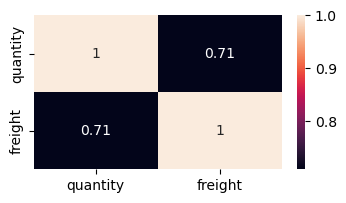

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4,2))
sns.heatmap(vendor_invoice[['quantity', 'freight']].corr(), annot=True)
plt.show()

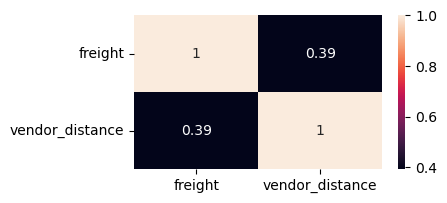

In [13]:
plt.figure(figsize=(4,2))
sns.heatmap(vendor_invoice[['freight', 'vendor_distance']].corr(), annot=True)
plt.show()

### Store-Level Analysis

In [12]:
store_summary = purchases.groupby("Store").agg({
    "Quantity": "sum",
    "Dollars": "sum"
}).reset_index()

store_summary.sort_values("Dollars", ascending=False).head()

,Store,Quantity,Dollars
27,28,55293,2328209.13
8,9,53519,2253299.95
45,46,51154,2243332.23
13,14,52665,2212717.89
44,45,53379,2202929.46


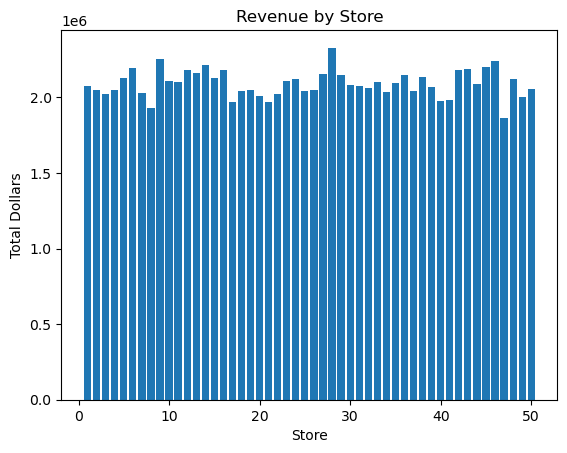

In [13]:
plt.bar(store_summary["Store"], store_summary["Dollars"])
plt.title("Revenue by Store")
plt.xlabel("Store")
plt.ylabel("Total Dollars")
plt.show()

### Vendor Invoice Analysis

In [14]:
vendor_invoice.describe()

,vendornumber,ponumber,invoicedate,podate,paydate,quantity,dollars,vendor_distance,vendor_rate,freight
count,49846.000000,49846.000000,49846,49846,49846,49846.000000,49846.000000,49846.000000,49846.000000,49846.000000
mean,1048.511054,55065.141937,2024-10-12 20:37:32.762508544,2024-10-03 23:51:09.598363136,2024-10-30 07:18:07.814468608,50.694098,2097.552682,498.151258,0.996847,83.628121
min,1000.000000,10000.000000,2024-04-09 00:00:00,2024-04-06 00:00:00,2024-04-15 00:00:00,1.000000,3.210000,55.246011,0.802781,5.490000
25%,1024.000000,32388.000000,2024-07-13 00:00:00,2024-07-04 00:00:00,2024-07-31 00:00:00,26.000000,655.080000,225.611733,0.895825,62.710000
50%,1048.000000,55180.000000,2024-10-13 00:00:00,2024-10-04 00:00:00,2024-10-30 00:00:00,51.000000,1607.225000,498.604179,0.998899,81.570000
75%,1072.000000,77760.750000,2025-01-13 00:00:00,2025-01-04 00:00:00,2025-01-30 00:00:00,76.000000,3142.380000,745.394245,1.104648,102.370000
max,1099.000000,99997.000000,2025-04-20 00:00:00,2025-04-05 00:00:00,2025-05-18 00:00:00,194.000000,10710.900000,987.542590,1.194260,243.450000
std,28.339629,26031.588190,NaN,NaN,NaN,29.076117,1766.336611,284.006355,0.117671,28.408428


In [15]:
vendor_summary = purchases.groupby("VendorName").agg({
    "Quantity": "sum",
    "Dollars": "sum",
    "PONumber": "nunique"
}).reset_index()

vendor_summary.sort_values("Dollars", ascending=False).head()

,VendorName,Quantity,Dollars,PONumber
33,Harrison PLC,70504,2344687.92,1385
3,Banks-King,55589,1996112.39,1105
55,"Moore, Watts and Nelson",42331,1981337.70,831
2,Ball LLC,47074,1951586.56,917
24,"Glenn, Hopkins and Davis",45745,1949774.21,906


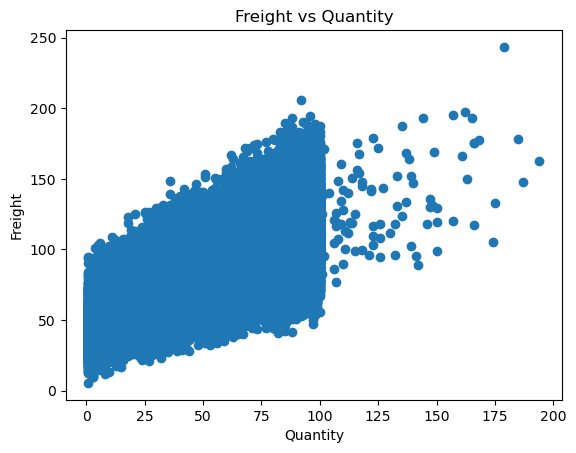

In [16]:
plt.scatter(vendor_invoice["quantity"], vendor_invoice["freight"])
plt.xlabel("Quantity")
plt.ylabel("Freight")
plt.title("Freight vs Quantity")
plt.show()

Freight increases with quantity

### Payment & Delay Analysis

In [17]:
purchases["payment_delay"] = (purchases["PayDate"] - purchases["InvoiceDate"]).dt.days

purchases["payment_delay"].describe()

count    50000.000000
mean        17.442460
std          7.490846
min          5.000000
25%         11.000000
50%         17.000000
75%         24.000000
max         30.000000
Name: payment_delay, dtype: float64

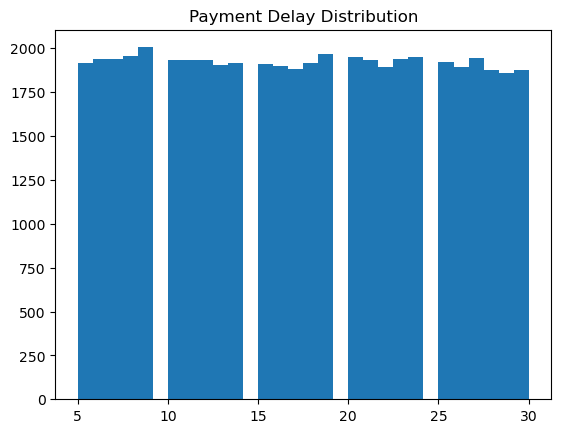

In [18]:
plt.hist(purchases["payment_delay"], bins=30)
plt.title("Payment Delay Distribution")
plt.show()

### High spend anomalies

In [19]:
threshold = purchases["Dollars"].quantile(0.99)

anomalies = purchases[purchases["Dollars"] > threshold]
anomalies.head()

,inventoryid,Store,Brand,Description,Size,VendorNo,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification,payment_delay
245,245,47,Quinn-Tran,Whether Product,Large,1039,"Vega, Meyers and Crawford",40250,2024-12-30,2025-01-05,2025-01-10,2025-01-22,77.56,91,7057.96,C,12
335,335,1,"West, Reed and Berry",From Product,Small,1031,Watson and Sons,23772,2024-04-26,2024-04-30,2024-05-03,2024-05-20,79.25,88,6974.00,B,17
355,355,12,Davis-Russell,Family Product,Medium,1091,"Chen, Peterson and Hawkins",95494,2024-07-12,2024-07-13,2024-07-18,2024-07-25,79.57,93,7400.01,C,7
442,442,4,Bell Ltd,Address Product,Medium,1097,"Garrett, Randall and Miller",85072,2025-02-10,2025-02-13,2025-02-15,2025-03-13,79.55,98,7795.90,A,26
519,519,50,Long Ltd,Area Product,Large,1069,Hamilton PLC,20765,2024-12-22,2024-12-25,2024-12-30,2025-01-29,73.81,97,7159.57,A,30
